<a href="https://colab.research.google.com/github/octaviareika/estudo-data-science/blob/main/estudo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.feature_selection import chi2, SelectKBest
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier


pd.set_option('display.max_rows', None)

In [ ]:
dataset = pd.read_csv("db.csv", sep=",")

In [ ]:
dataset.dtypes

,0
id_produto,int64
nome,object
categoria,object
preco,float64
estoque,int64
avaliacao_clientes,float64


In [ ]:
dataset

,id_produto,nome,categoria,preco,estoque,avaliacao_clientes
0,1,Teclado Mecânico,Periféricos,250.0,45,4.8
1,2,Monitor 24 Pol,Hardware,1200.0,12,4.5
2,3,Mouse Gamer,Periféricos,150.5,60,4.2
3,4,Memória RAM 16GB,Hardware,380.0,25,4.9
4,5,Cadeira Office,Móveis,850.0,8,3.9
5,6,Headset Bluetooth,Áudio,320.0,15,4.6
6,7,Webcam 1080p,Acessórios,210.0,0,4.0
7,8,SSD 1TB,Hardware,450.0,30,4.7
8,9,Suporte Articulado,Acessórios,180.0,20,4.3
9,10,Caixa de Som USB,Áudio,85.0,50,3.5


In [ ]:
dataset['nome']

,nome
0,Teclado Mecânico
1,Monitor 24 Pol
2,Mouse Gamer
3,Memória RAM 16GB
4,Cadeira Office
5,Headset Bluetooth
6,Webcam 1080p
7,SSD 1TB
8,Suporte Articulado
9,Caixa de Som USB


[[2 2]
 [1 3]]


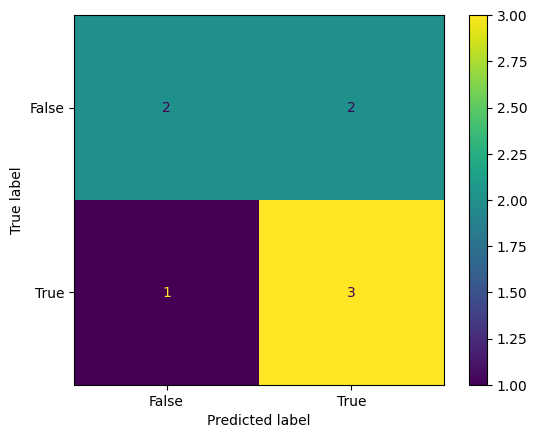

In [ ]:
# prever se um produto terá estoque baixo (True ou false)

y_real = [1, 0, 1, 1, 0, 1, 0, 0]
y_pred = [1, 1, 1, 0, 0, 1, 1, 0]

#Criar a matriz
matriz = confusion_matrix(y_real, y_pred)
print(matriz)

vis = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=[False, True])
vis.plot()
plt.show()


In [ ]:
y_real = [250, 1200, 150.50, 380] # Valores reais (tirados do seu CSV)

# Valores que a IA chutou

y_pred = [230, 1250, 160, 350]

print({mean_absolute_error(y_real, y_pred)}) # MAE
print({r2_score(y_real, y_pred)}) #R2
print({mean_squared_error(y_real, y_pred)}) #mse

{27.375}
{0.9943534063309452}
{972.5625}


In [ ]:
X = np.array([[50], [70], [80], [100], [120]])
# Preços correspondentes: [Milhares de Reais]
y = np.array([200, 280, 310, 390, 450])

# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Prever o preço de uma casa de 90m2
previsao = modelo.predict([[90]])
print(f"Preço estimado para 90m2: R$ {previsao[0]:.2f} mil")

Preço estimado para 90m2: R$ 347.53 mil


In [ ]:
# X numero de amigos, y = Minutos por dia
dados = {
    'num_amigos' : [1, 2, 3, 5, 8, 10, 12, 16, 18, 23],
    'minutos_no_site': [5, 12, 15, 22, 35, 40, 43, 50, 55, 60]

}

df = pd.DataFrame(dados)
df

,num_amigos,minutos_no_site
0,1,5
1,2,12
2,3,15
3,5,22
4,8,35
5,10,40
6,12,43
7,16,50
8,18,55
9,23,60


In [ ]:
# O modelo espera que X seja uma matriz
X = df[['num_amigos']]
y = df[['minutos_no_site']]

X, y

(   num_amigos
 0           1
 1           2
 2           3
 3           5
 4           8
 5          10
 6          12
 7          16
 8          18
 9          23,
    minutos_no_site
 0                5
 1               12
 2               15
 3               22
 4               35
 5               40
 6               43
 7               50
 8               55
 9               60)

In [ ]:
modelo = LinearRegression()
modelo.fit(X, y)

# Se o usuario fizer 7 amigos
novo_usuario = [[7]]
previsao = modelo.predict(novo_usuario)


previsao

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[26.65254237]])

**MACHINE LEARNING**

In [3]:
iris = datasets.load_iris()
X_treinamento, X_teste, y_reinamento, y_teste = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)

In [5]:
modelo = MLPClassifier(
    verbose=True,
    hidden_layer_sizes=(5,4),
    activation='relu',
    batch_size=20,
    learning_rate='adaptive',
    momentum=0.9,
    early_stopping=False,
    max_iter=1000, # epocas
    random_state=10
)

modelo.fit(X_treinamento, y_reinamento)
previsoes = modelo.predict(X_teste)

Iteration 1, loss = 1.86199863
Iteration 2, loss = 1.78774059
Iteration 3, loss = 1.71916423
Iteration 4, loss = 1.65482437
Iteration 5, loss = 1.59646768
Iteration 6, loss = 1.54494999
Iteration 7, loss = 1.49711949
Iteration 8, loss = 1.45115777
Iteration 9, loss = 1.41039240
Iteration 10, loss = 1.37009929
Iteration 11, loss = 1.33470225
Iteration 12, loss = 1.29813287
Iteration 13, loss = 1.26521765
Iteration 14, loss = 1.23785768
Iteration 15, loss = 1.21723789
Iteration 16, loss = 1.20077631
Iteration 17, loss = 1.18917561
Iteration 18, loss = 1.17892593
Iteration 19, loss = 1.17039574
Iteration 20, loss = 1.16311270
Iteration 21, loss = 1.15636507
Iteration 22, loss = 1.15022374
Iteration 23, loss = 1.14390052
Iteration 24, loss = 1.13758739
Iteration 25, loss = 1.13104511
Iteration 26, loss = 1.12496344
Iteration 27, loss = 1.11836293
Iteration 28, loss = 1.11233657
Iteration 29, loss = 1.10685832
Iteration 30, loss = 1.10070925
Iteration 31, loss = 1.09485627
Iteration 32, los